# Image inpainting and outpainting with FLUX.1 Fill

inpainting is task of replacing or editing specific area of input image. This makes it a useful tool for image restoration like removing defects and artifacts, or even replacing an image area with something entirely new. Inpainting relies on a mask to determine which regions of an image to fill in; the area to inpaint is represented by white pixels and the area to keep is represented by black pixels. The white pixels are filled in by the prompt.
FLUX.1 Fill introduces advanced inpainting capabilities that surpass existing approaches.  It allows for seamless edits that integrate naturally with existing images. 

![](https://github.com/user-attachments/assets/3598a8e1-526b-4571-8d73-200dcde92430)

Additionally, FLUX.1 Fill supports outpainting, enabling the user to extend images beyond their original borders.

![](https://github.com/user-attachments/assets/0e195ef2-fc5d-4eca-b32f-08cdd646199f)

You can find more details about model in [blog post](https://blackforestlabs.ai/flux-1-tools/) and [model card](https://huggingface.co/black-forest-labs/FLUX.1-Fill-dev)

In this tutorial, we consider how to convert and optimize FLUX.1 Fill for performing image editing using text prompt and binary mask. You will learn how to convert model using [Optimum Intel](https://github.com/huggingface/optimum-intel), optimize it using [NNCF](https://github.com/openvinotoolkit/nncf) and run with [OpenVINO GenAI](https://github.com/openvinotoolkit/openvino.genai)

#### Table of contents:

- [Prerequisites](#Prerequisites)
- [Convert model with OpenVINO](#Convert-model-with-OpenVINO)
    - [Convert model using Optimum Intel](#Convert-model-using-Optimum-Intel)
    - [Compress model weights](#Compress-model-weights)
- [Run OpenVINO model inference](#Run-OpenVINO-model-inference)
- [Interactive demo](#Interactive-demo)


### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).

<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/flux-fill/flux-fill.ipynb" />


## Prerequisites
[back to top ⬆️](#Table-of-contents:)

In [1]:
import platform
import requests
from pathlib import Path

utility_files = ["cmd_helper.py", "notebook_utils.py"]
base_utility_url = "https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/"

for utility_file in utility_files:
    if not Path(utility_file).exists():
        r = requests.get(base_utility_url + utility_file)
        with Path(utility_file).open("w") as f:
            f.write(r.text)

%pip install -q "gradio>=4.19" "torch>=2.1"  "transformers" "diffusers>=0.32.0" "opencv-python" "pillow" "peft>=0.7.0" --extra-index-url https://download.pytorch.org/whl/cpu
%pip install -q "sentencepiece" "protobuf"
%pip install -q "git+https://github.com/huggingface/optimum-intel.git" "nncf>=2.16.0"  --extra-index-url https://download.pytorch.org/whl/cpu
%pip install -qU --pre "openvino>=2025.1.0" "openvino-genai" "openvino-tokenizers" --extra-index-url https://storage.openvinotoolkit.org/simple/wheels/nightly

if platform.system() == "Darwin":
    %pip install -q "numpy<2.0"

>**Note**: run Flux.1-Fill-dev model with notebook, you will need to accept license agreement. 
>You must be a registered user in 🤗 Hugging Face Hub. Please visit [HuggingFace model card](https://huggingface.co/black-forest-labs/FLUX.1-Fill-dev), carefully read the terms of usage, and click the accept button.  You will need to use an access token for the code below to run. For more information on access tokens, refer to [this section of the documentation](https://huggingface.co/docs/hub/security-tokens).
>You can login on to Hugging Face Hub in the notebook environment, using the following code:

In [2]:
# uncomment these lines to login to huggingfacehub to get access to pretrained model

# from huggingface_hub import notebook_login, whoami

# try:
#     whoami()
#     print('Authorization token already provided')
# except OSError:
#     notebook_login()

# Convert model with OpenVINO
[back to top ⬆️](#Table-of-contents:)

Starting from 2023.0 release, OpenVINO supports PyTorch models directly via Model Conversion API. `ov.convert_model` function accepts instance of PyTorch model and example inputs for tracing and returns object of `ov.Model` class, ready to use or save on disk using `ov.save_model` function. 


The pipeline consists of four important parts:

* Clip and T5 Text Encoders to create condition to generate an image from a text prompt.
* Transformer for step-by-step denoising latent image representation.
* Autoencoder (VAE) for encoding input image and mask and  decoding latent space to image.
  
### Convert model using Optimum Intel
[back to top ⬆️](#Table-of-contents:)

For convenience, we will use OpenVINO integration with HuggingFace Optimum. 🤗 [Optimum Intel](https://huggingface.co/docs/optimum/intel/index) is the interface between the 🤗 Transformers and Diffusers libraries and the different tools and libraries provided by Intel to accelerate end-to-end pipelines on Intel architectures.

Among other use cases, Optimum Intel provides a simple interface to optimize your Transformers and Diffusers models, convert them to the OpenVINO Intermediate Representation (IR) format and run inference using OpenVINO Runtime. `optimum-cli` provides command line interface for model conversion and optimization. 

General command format:

```bash
optimum-cli export openvino --model <model_id_or_path> --task <task> <output_dir>
```

where task is task to export the model for, if not specified, the task will be auto-inferred based on the model. You can find a mapping between tasks and model classes in Optimum TaskManager [documentation](https://huggingface.co/docs/optimum/exporters/task_manager). Additionally, you can specify weights compression using `--weight-format` argument with one of following options: `fp32`, `fp16`, `int8` and `int4`. Fro int8 and int4 [nncf](https://github.com/openvinotoolkit/nncf) will be used for  weight compression. More details about model export provided in [Optimum Intel documentation](https://huggingface.co/docs/optimum/intel/openvino/export#export-your-model).

### Compress model weights
[back to top ⬆️](#Table-of-contents:)

For reducing model memory consumption we will use weights compression. The [Weights Compression](https://docs.openvino.ai/2024/openvino-workflow/model-optimization-guide/weight-compression.html) algorithm is aimed at compressing the weights of the models and can be used to optimize the model footprint and performance of large models where the size of weights is relatively larger than the size of activations, for example, Large Language Models (LLM). Compared to INT8 compression, INT4 compression improves performance even more, but introduces a minor drop in prediction quality. We will use [NNCF](https://github.com/openvinotoolkit/nncf) integration to `optimum-cli` tool for weight compression.


In [3]:
from cmd_helper import optimum_cli
import ipywidgets as widgets

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("flux-fill.ipynb")

to_compress = widgets.Checkbox(
    value=True,
    description="Weight compression",
    disabled=False,
)

to_compress

/home/ea/work/my_optimum_intel/optimum_env_new/lib/python3.11/site-packages/openvino/runtime/__init__.py:10: DeprecationWarning: The `openvino.runtime` module is deprecated and will be removed in the 2026.0 release. Please replace `openvino.runtime` with `openvino`.
  warnings.warn(


Checkbox(value=True, description='Weight compression')

In [4]:
model_id = "black-forest-labs/FLUX.1-Fill-dev"

model_base_dir = Path(model_id.split("/")[-1])
additional_args = {}

if to_compress.value:
    model_dir = model_base_dir / "INT4"
    additional_args.update({"weight-format": "int4", "group-size": "64", "ratio": "1.0"})
else:
    model_dir = model_base_dir / "FP16"
    additional_args.update({"weight-format": "fp16"})

if not model_dir.exists():
    optimum_cli(model_id, model_dir, additional_args=additional_args)

## Run OpenVINO model inference
[back to top ⬆️](#Table-of-contents:)

[OpenVINO™ GenAI](https://github.com/openvinotoolkit/openvino.genai) is a library of the most popular Generative AI model pipelines, optimized execution methods, and samples that run on top of highly performant OpenVINO Runtime.

This library is friendly to PC and laptop execution, and optimized for resource consumption. It requires no external dependencies to run generative models as it already includes all the core functionality (e.g. tokenization via openvino-tokenizers).

OpenVINO GenAI supports popular diffusion models like Stable Diffusion or SDXL for performing image generation. You can find supported models list in [OpenVINO GenAI documentation](https://openvinotoolkit.github.io/openvino.genai/docs/supported-models/#image-generation-models).


For creation OpenVINO GenAI Inpainting pipeline `openvino_genai.InpaintingPipeline` should be used. The pipeline accepts directory with converted model and inference device. Let's select execution device:

In [5]:
from notebook_utils import device_widget

device = device_widget(default="CPU", exclude=["NPU"])
device

Dropdown(description='Device:', options=('CPU', 'AUTO'), value='CPU')

In [6]:
import ipywidgets as widgets

model_available = (model_base_dir / "INT4").is_dir()
use_quantized_models = widgets.Checkbox(
    value=model_available,
    description="Use compressed models",
    disabled=not model_available,
)

use_quantized_models

Checkbox(value=True, description='Use compressed models')

In [7]:
import openvino_genai as ov_genai

model_dir = model_base_dir / "INT4" if use_quantized_models.value else model_base_dir / "FP16"

ov_pipe = ov_genai.InpaintingPipeline(model_dir, device=device.value)

The main inputs for inpainting are input text prompt, image and mask for editing region for image. Input prompt is represented by text string that contains user's instructions for pipeline guidance. Input image and mask should be provided as `ov.Tensor`. The code bellow demonstrates how to convert image after reading Pillow library to OpenVINO tensor. You also can pass some additional advanced options for better controlling generation process. We consider the most useful from them in next sections.

In [8]:
from diffusers.utils import load_image, make_image_grid
import openvino as ov
import numpy as np
from PIL import Image

input_image_path = Path("input_image.png")
input_mask_path = Path("input_mask.png")

if not input_image_path.exists():
    init_image = load_image("https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo.png")
    init_image.save(input_image_path)
else:
    init_image = load_image(str(input_image_path))

if not input_mask_path.exists():
    init_mask = load_image("https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo_mask.png")
    init_mask.save(input_mask_path)
else:
    init_mask = load_image(str(input_mask_path))


def image_to_tensor(image: Image) -> ov.Tensor:
    pic = image.convert("RGB")
    image_data = np.array(pic.getdata()).reshape(1, pic.size[1], pic.size[0], 3).astype(np.uint8)
    return ov.Tensor(image_data)

When pipeline initialized, we can see model in action. Let's try to turn dog to cat!

For starting generation process, `generate` method should be used. Together with input prompt, mask and image, we also provided `generator`, pseudo-random numbers generator that responsible for results reproducibility. We will use `ov_genai.TorchGenerator` helper, the behavior of this generator is aligned with PyTorch. It means you can get result as much close to original diffusion pipeline as possible. `callback` argument allows early stopping generation if we decided that we are satisfied generation results when `num_inference_steps` has not been not reached yet, but it also can be useful for some other cases as well. In this tutorial, we will use it for adding interactive progress bar.

0it [00:00, ?it/s]

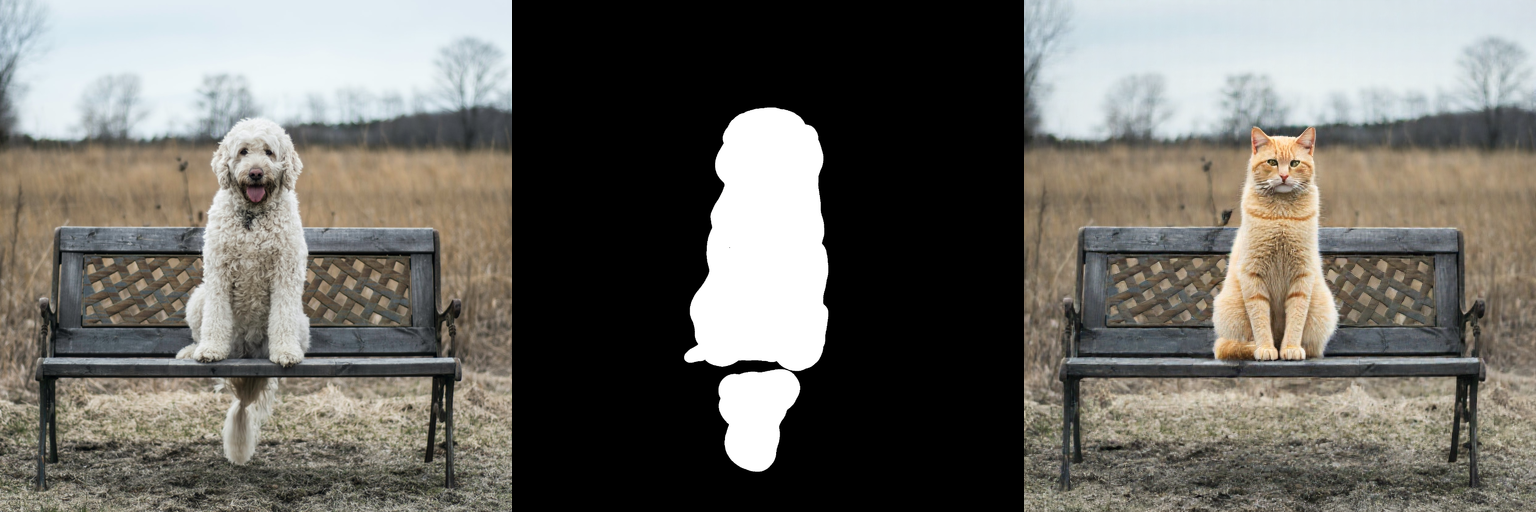

In [9]:
from tqdm.notebook import tqdm
import sys

pbar = tqdm(20)


def callback(step, num_steps, latent):
    if pbar.total != num_steps:
        pbar.reset(num_steps)
    pbar.update(1)
    sys.stdout.flush()
    return False


generator = ov_genai.TorchGenerator(92)
prompt = "A yellow cat, high resolution, sitting on a park bench"
image = ov_pipe.generate(
    prompt=prompt,
    image=image_to_tensor(init_image),
    mask_image=image_to_tensor(init_mask),
    num_inference_steps=20,
    height=512,
    width=512,
    generator=generator,
    callback=callback,
)

pbar.close()
image = Image.fromarray(image.data[0])
make_image_grid([init_image, init_mask, image], rows=1, cols=3)

## Interactive demo
[back to top ⬆️](#Table-of-contents:)

In [10]:
if not Path("gradio_helper.py").exists():
    r = requests.get("https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/notebooks/flux-fill.gradio_helper.py")
    with open("grdio_helper.py", "w") as f:
        f.write(r.text)


from gradio_helper import make_demo

demo = make_demo(ov_pipe)

try:
    demo.launch(debug=True)
except Exception:
    demo.launch(share=True, debug=True)
# if you are launching remotely, specify server_name and server_port
# demo.launch(server_name='your server name', server_port='server port in int')
# Read more in the docs: https://gradio.app/docs/

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


  0%|          | 0/28 [00:00<?, ?steps/s]

Keyboard interruption in main thread... closing server.
